## 1- Instalação das Bibliotecas

In [ ]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

  Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl (10.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 9.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 11.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2 - Limpeza de dados

In [2]:
import os 
print(os.getcwd())

/Users/u24139/Documents/GitHub/WaterPath_TCC/back-end/ia/app/services/Predict/Notes


In [3]:
data = pd.read_csv(os.getcwd()+"/station/china_water_pollution_data.csv",low_memory=True)
df = pd.DataFrame(data)
df







,Province,City,Monitoring_Station,Latitude,Longitude,Date,Water_Temperature_C,pH,Dissolved_Oxygen_mg_L,Conductivity_uS_cm,...,Total_Nitrogen_mg_L,COD_mg_L,BOD_mg_L,Heavy_Metals_Pb_ug_L,Heavy_Metals_Cd_ug_L,Heavy_Metals_Hg_ug_L,Coliform_Count_CFU_100mL,Water_Quality_Index,Pollution_Level,Remarks
0,Zhejiang,Ningbo,Ningbo_Station_2,25.523836,122.622036,2023-06-01,22.48,6.93,9.30,652.30,...,2.71,15.38,1.39,6.90,0.66,0.02,87,36.64,Very Poor,High pollution spike detected
1,Sichuan,Mianyang,Mianyang_Station_1,32.243099,112.888760,2023-03-05,27.33,6.89,8.14,357.53,...,3.15,16.82,2.98,4.68,0.39,0.10,116,66.25,Excellent,High pollution spike detected
2,Zhejiang,Ningbo,Ningbo_Station_8,29.996179,124.744859,2023-07-13,21.04,6.02,5.34,519.69,...,3.39,17.31,2.65,3.24,0.27,0.11,110,98.69,Poor,High pollution spike detected
3,Beijing,Beijing,Beijing_Station_10,29.976437,118.274846,2023-02-17,16.62,7.31,10.06,593.13,...,2.91,17.95,5.18,3.20,0.67,0.11,99,71.32,Poor,Monitoring recommended
4,Sichuan,Chengdu,Chengdu_Station_1,43.524720,121.666111,2023-03-06,21.81,7.77,7.93,656.46,...,3.45,20.10,3.47,2.01,0.34,0.14,82,16.12,Excellent,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Shandong,Qingdao,Qingdao_Station_6,28.766067,100.662530,2023-11-03,14.26,6.68,8.83,465.49,...,3.34,13.18,2.32,5.61,0.49,0.11,115,9.18,Moderate,Monitoring recommended
2996,Guangdong,Shenzhen,Shenzhen_Station_3,34.608605,121.475802,2023-07-22,22.29,7.26,8.89,606.39,...,3.66,18.86,4.40,5.70,0.53,0.19,107,48.35,Excellent,
2997,Shandong,Jinan,Jinan_Station_1,36.642090,102.593904,2023-06-29,26.02,6.08,6.91,378.42,...,2.35,20.42,4.58,5.55,0.62,0.05,102,61.78,Poor,Monitoring recommended
2998,Sichuan,Chengdu,Chengdu_Station_4,25.261258,119.203392,2023-01-10,22.64,6.77,8.11,462.59,...,2.73,21.58,3.50,-1.55,0.44,0.06,115,72.10,Good,Requires attention


In [4]:
df.columns = df.columns.str.strip()
features = [
    "Water_Temperature_C",
    "pH",
    "Dissolved_Oxygen_mg_L",
    "Conductivity_uS_cm",
    "Turbidity_NTU",
    "Nitrate_mg_L",
    "Nitrite_mg_L",
    "Ammonia_N_mg_L",
    "Total_Phosphorus_mg_L",
    "Total_Nitrogen_mg_L",
    "COD_mg_L",
    "BOD_mg_L"
]

result = [
    "Heavy_Metals_Pb_ug_L",
    "Heavy_Metals_Cd_ug_L",
    "Heavy_Metals_Hg_ug_L"
]

df = df[features + result].copy().dropna()
for columns in features + result:
    df[columns] = pd.to_numeric(df[columns], errors='coerce')
    
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Water_Temperature_C    3000 non-null   float64
 1   pH                     3000 non-null   float64
 2   Dissolved_Oxygen_mg_L  3000 non-null   float64
 3   Conductivity_uS_cm     3000 non-null   float64
 4   Turbidity_NTU          3000 non-null   float64
 5   Nitrate_mg_L           3000 non-null   float64
 6   Nitrite_mg_L           3000 non-null   float64
 7   Ammonia_N_mg_L         3000 non-null   float64
 8   Total_Phosphorus_mg_L  3000 non-null   float64
 9   Total_Nitrogen_mg_L    3000 non-null   float64
 10  COD_mg_L               3000 non-null   float64
 11  BOD_mg_L               3000 non-null   float64
 12  Heavy_Metals_Pb_ug_L   3000 non-null   float64
 13  Heavy_Metals_Cd_ug_L   3000 non-null   float64
 14  Heavy_Metals_Hg_ug_L   3000 non-null   float64
dtypes: float64(15)


## 3 Treinamento da IA


In [5]:
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import ensemble
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



### Geração de modelos para cada metal pesado


In [8]:
models = {}
print("\nTREINANDO MODELOS DE REGRESSÃO PARA CADA METAL PESADO")
X,Y = df[features], df[result]
XTrain, XTest, YTrain, YTest = model_selection.train_test_split(X,Y,test_size=0.5, random_state=42)
for metal in result:
    rf = ensemble.RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(XTrain, YTrain[metal])
    rf_pred = rf.predict(XTest)
    mae = mean_absolute_error(YTest[metal], rf_pred)
    mse = mean_squared_error(YTest[metal], rf_pred)
    r2 = r2_score(YTest[metal], rf_pred)
    
    ###Treino gerando importancia das features
    importance = pd.DataFrame({
        "Feature": features,
        "Importance": rf.feature_importances_
    })
    
    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )
    
    print("\nIMPORTÂNCIA DAS FEATURES")

    print(importance.to_string(index=False))
    models[metal] = rf
    
    
models
    




TREINANDO MODELOS DE REGRESSÃO PARA CADA METAL PESADO

IMPORTÂNCIA DAS FEATURES
              Feature  Importance
  Water_Temperature_C    0.096390
             COD_mg_L    0.091387
                   pH    0.087836
             BOD_mg_L    0.087681
Dissolved_Oxygen_mg_L    0.084809
   Conductivity_uS_cm    0.083109
  Total_Nitrogen_mg_L    0.082847
Total_Phosphorus_mg_L    0.079825
         Nitrite_mg_L    0.079672
         Nitrate_mg_L    0.077764
       Ammonia_N_mg_L    0.074374
        Turbidity_NTU    0.074307

IMPORTÂNCIA DAS FEATURES
              Feature  Importance
   Conductivity_uS_cm    0.094690
Dissolved_Oxygen_mg_L    0.093754
Total_Phosphorus_mg_L    0.087023
  Water_Temperature_C    0.086561
         Nitrate_mg_L    0.085574
             BOD_mg_L    0.084538
  Total_Nitrogen_mg_L    0.082368
        Turbidity_NTU    0.081078
                   pH    0.080292
             COD_mg_L    0.079049
         Nitrite_mg_L    0.072880
       Ammonia_N_mg_L    0.072194

IMPORTÂN

{'Heavy_Metals_Pb_ug_L': RandomForestRegressor(random_state=42),
 'Heavy_Metals_Cd_ug_L': RandomForestRegressor(random_state=42),
 'Heavy_Metals_Hg_ug_L': RandomForestRegressor(random_state=42)}

### Teste dos modelos gerados

In [8]:
for metal,model in models.items():
    predtictios = model.predict(XTest)
    realValues = YTest[metal].values
    
    mae = mean_absolute_error(realValues, predtictios)
    mse = mean_squared_error(realValues, predtictios)
    r2 = r2_score(realValues, predtictios)
    
    print(f"\n{metal}")
    print(f"MAE : {mae}")
    print(f"MSE : {mse}")
    print(f"R²  : {r2}")
    


Heavy_Metals_Pb_ug_L
MAE : 1.646209222222222
MSE : 4.372951917077778
R²  : -0.02947415080451643

Heavy_Metals_Cd_ug_L
MAE : 0.15871088888888887
MSE : 0.04041729437777778
R²  : -0.04034425064359515

Heavy_Metals_Hg_ug_L
MAE : 0.03953888888888889
MSE : 0.002466007088888889
R²  : -0.04889198716270737


### Comparando o teste com o valor real

In [9]:
for metal,model in models.items():
    predtictios = model.predict(XTest)
    realValues = YTest[metal].values
    
    mae = mean_absolute_error(realValues, predtictios)
    mse = mean_squared_error(realValues, predtictios)
    r2 = r2_score(realValues, predtictios)
    
    print(f"\n{metal}")
    print(f"MAE : {mae}")
    print(f"MSE : {mse}")
    print(f"R²  : {r2}")
    
    print(f"\n Comparando valores reais e preditos para {metal}")
    for pred, real in zip(predtictios[:10], realValues[:10]):
        print(f"Predito: {pred:.2f} | Real: {real:.2f}")


Heavy_Metals_Pb_ug_L
MAE : 1.6260096
MSE : 4.254966566053334
R²  : -0.028249557302133077

 Comparando valores reais e preditos para Heavy_Metals_Pb_ug_L
Predito: 4.93 | Real: 4.85
Predito: 5.65 | Real: 5.99
Predito: 4.79 | Real: 4.45
Predito: 5.15 | Real: 4.09
Predito: 5.40 | Real: 0.99
Predito: 5.34 | Real: 2.97
Predito: 5.27 | Real: 5.12
Predito: 4.90 | Real: 4.32
Predito: 5.01 | Real: 0.97
Predito: 5.19 | Real: 5.94

Heavy_Metals_Cd_ug_L
MAE : 0.1569568
MSE : 0.039437899453333335
R²  : -0.028503133687020066

 Comparando valores reais e preditos para Heavy_Metals_Cd_ug_L
Predito: 0.51 | Real: 0.65
Predito: 0.43 | Real: 0.52
Predito: 0.48 | Real: 0.46
Predito: 0.51 | Real: 0.43
Predito: 0.45 | Real: 0.57
Predito: 0.46 | Real: 0.60
Predito: 0.47 | Real: 0.78
Predito: 0.51 | Real: 0.18
Predito: 0.55 | Real: 0.13
Predito: 0.52 | Real: 0.39

Heavy_Metals_Hg_ug_L
MAE : 0.04018526666666667
MSE : 0.00251580774
R²  : -0.0591885425026315

 Comparando valores reais e preditos para Heavy_Metals

### Grafíco da importância dos parametrôs fisico-quimicos

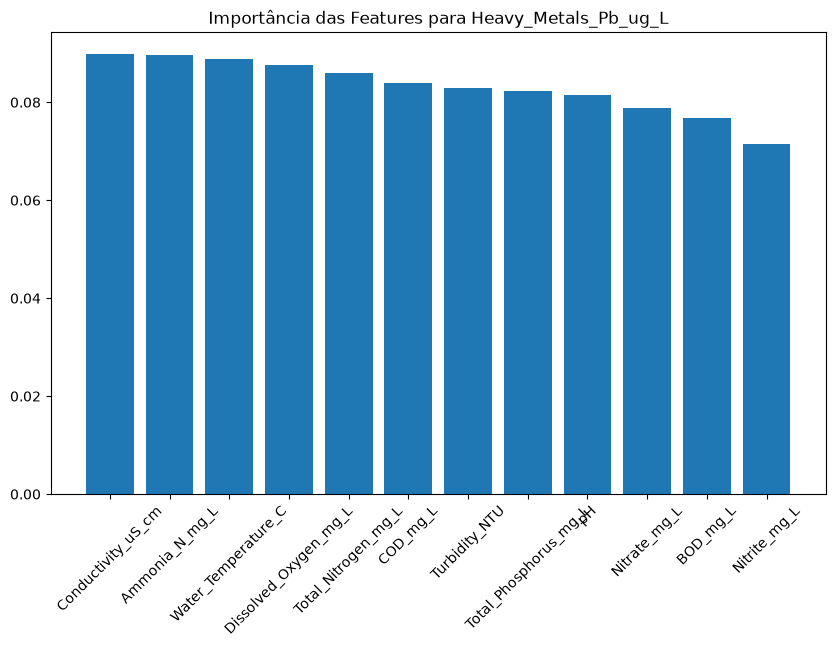

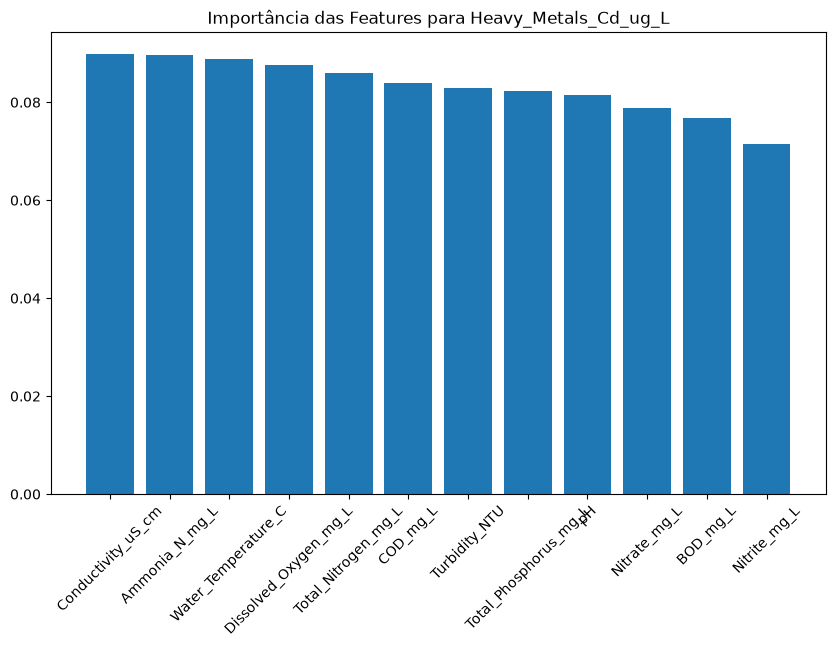

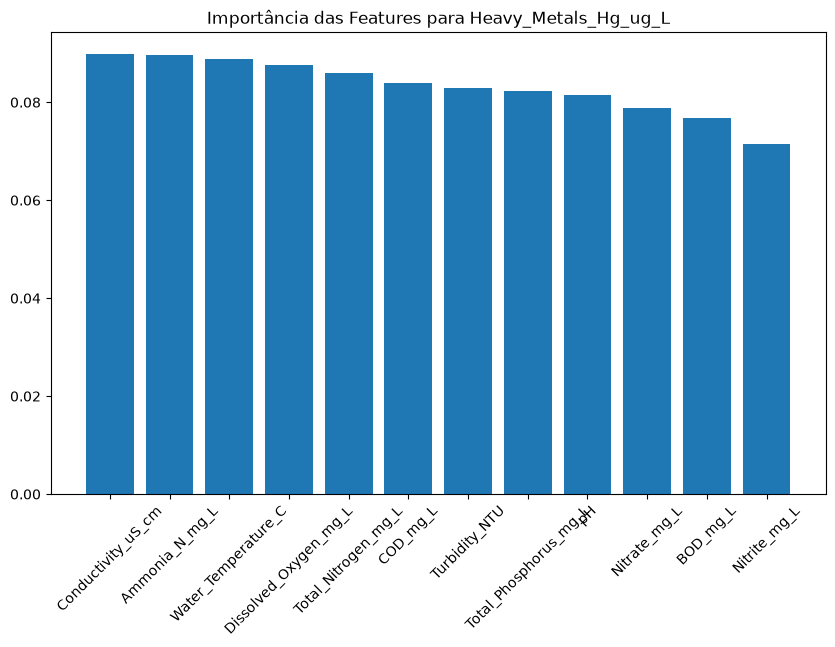

In [ ]:
for model in models:
    plt.figure(figsize=(10,6))
    plt.title(f"Importância das Features para {model}")
    plt.bar(importance["Feature"], importance["Importance"])
    plt.xticks(rotation=45)
    plt.show()